<a href="https://colab.research.google.com/github/malick08012/Movie-Recommendation-System/blob/main/Movie_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

**Upload Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving u.data to u.data
Saving u.item to u.item


**Load Ratings Dataset**

In [3]:
ratings = pd.read_csv(
    "u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

ratings.head()

,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


**Load Movies Dataset**

In [4]:
movies = pd.read_csv(
    "u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0,1],
    names=["movieId", "title"]
)

movies.head()

,movieId,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


**Explore Dataset**

In [5]:
print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)

print("Total Users:", ratings['userId'].nunique())
print("Total Movies:", ratings['movieId'].nunique())

Ratings Shape: (100000, 4)
Movies Shape: (1682, 2)
Total Users: 943
Total Movies: 1682


**Create User-Item Matrix**

In [6]:
user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Fill Missing Values**

In [7]:
user_item_matrix = user_item_matrix.fillna(0)

**Compute User Similarity**

In [8]:
user_similarity = cosine_similarity(user_item_matrix)

**Convert it to dataframe for easier use.**

In [9]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475,0.430239,0.440367,0.319072,0.078138,0.376544,...,0.369527,0.119482,0.274876,0.189705,0.197326,0.118095,0.314072,0.148617,0.179508,0.398175
2,0.166931,1.000000,0.110591,0.178121,0.072979,0.245843,0.107328,0.103344,0.161048,0.159862,...,0.156986,0.307942,0.358789,0.424046,0.319889,0.228583,0.226790,0.161485,0.172268,0.105798
3,0.047460,0.110591,1.000000,0.344151,0.021245,0.072415,0.066137,0.083060,0.061040,0.065151,...,0.031875,0.042753,0.163829,0.069038,0.124245,0.026271,0.161890,0.101243,0.133416,0.026556
4,0.064358,0.178121,0.344151,1.000000,0.031804,0.068044,0.091230,0.188060,0.101284,0.060859,...,0.052107,0.036784,0.133115,0.193471,0.146058,0.030138,0.196858,0.152041,0.170086,0.058752
5,0.378475,0.072979,0.021245,0.031804,1.000000,0.237286,0.373600,0.248930,0.056847,0.201427,...,0.338794,0.080580,0.094924,0.079779,0.148607,0.071459,0.239955,0.139595,0.152497,0.313941


**Convert Movie IDs to Movie Titles**

In [10]:
def recommend_movies(user_id, num_recommendations=5):

    # Find similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    similar_users_ids = similar_users.index

    # Movies watched by similar users
    similar_users_movies = user_item_matrix.loc[similar_users_ids]

    # Average ratings of those movies
    movie_scores = similar_users_movies.mean(axis=0)

    # Movies already watched by the target user
    watched_movies = user_item_matrix.loc[user_id]

    # Filter unseen movies
    movie_scores = movie_scores[watched_movies == 0]

    # Top recommended movies
    recommended_movies = movie_scores.sort_values(ascending=False).head(num_recommendations)

    return recommended_movies

**Test the Recommendation System**

In [11]:
def get_movie_titles(movie_ids):

    return movies[movies["movieId"].isin(movie_ids)]["title"]

**Test the Recommendation System**

In [12]:
recommended = recommend_movies(10)

get_movie_titles(recommended.index)

,title
186,"Godfather: Part II, The (1974)"
208,This Is Spinal Tap (1984)
317,Schindler's List (1993)
426,To Kill a Mockingbird (1962)
489,To Catch a Thief (1955)


**Precision@K Evaluation**

In [13]:
def precision_at_k(user_id, recommended_movies, k=5):

    relevant_movies = ratings[
        (ratings["userId"] == user_id) &
        (ratings["rating"] >= 4)
    ]["movieId"]

    recommended_k = recommended_movies[:k]

    relevant_set = set(relevant_movies)
    recommended_set = set(recommended_k)

    precision = len(recommended_set & relevant_set) / k

    return precision

**Calculate Precision@5**

In [14]:
recommended = recommend_movies(10)

precision = precision_at_k(10, recommended.index, k=5)

print("Precision@5:", precision)

Precision@5: 0.0


**Visualization**

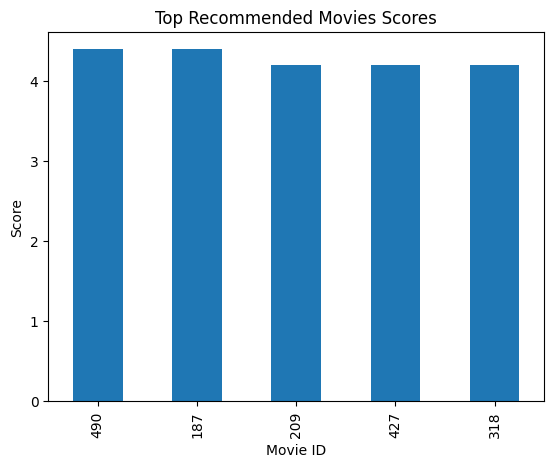

In [15]:
recommended = recommend_movies(10)

recommended.plot(kind="bar")

plt.title("Top Recommended Movies Scores")
plt.xlabel("Movie ID")
plt.ylabel("Score")
plt.show()